# Customer Churn Analysis using Machine Learning

## Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Step 2: Load the Dataset

In [ ]:
df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Step 3: Display Dataset

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


## Step 4: Display Column Names

In [ ]:
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


## Step 5: Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


## Step 6: Check Missing Values

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


## Step 7: Churn Distribution

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,33881
1,30493


In [ ]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


## Step 8: Remove Customer ID

In [ ]:
df = df.drop("CustomerID", axis=1)

## Step 9: Encode Categorical Data

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

print("Encoding Completed!")

Encoding Completed!


## Step 10: Split Features and Target

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Step 11: Train and Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Dataset Split Successfully!")

Dataset Split Successfully!


## Step 12: Train Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Step 13: Make Predictions

In [ ]:
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


## Step 14: Model Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8306019417475728


## Step 15: Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[5639 1154]
 [1027 5055]]


## Step 16: Confusion Matrix Heatmap

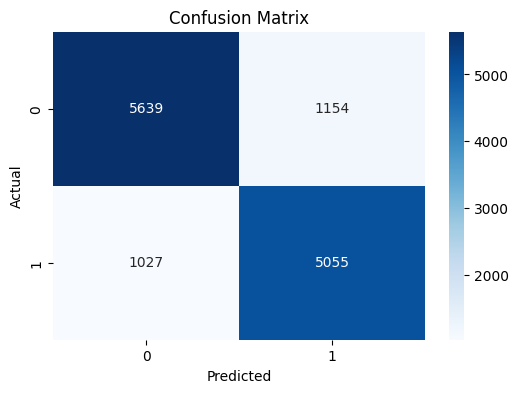

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 17: Age Distribution

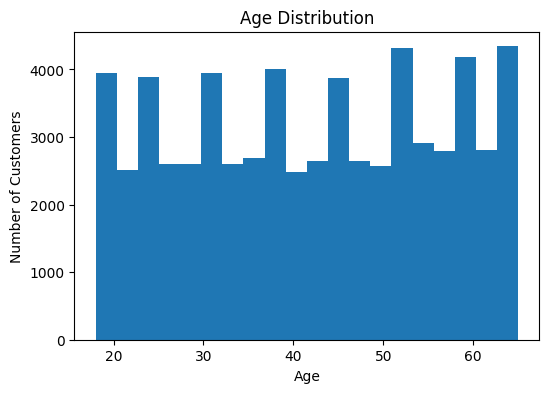

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

## Step 18: Contract Length Distribution

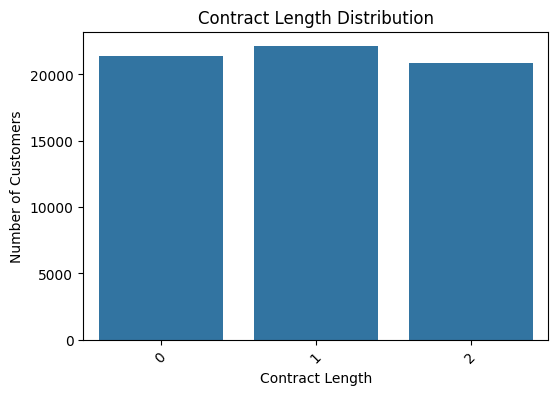

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract Length', data=df)
plt.title("Contract Length Distribution")
plt.xlabel("Contract Length")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## Step 17: Conclusion

This project predicts customer churn using Machine Learning. After preprocessing the data and training a Logistic Regression model, the model was able to classify customers as likely to churn or not churn with good accuracy.